In [26]:
import kagglehub
path = kagglehub.dataset_download("atharvaarya25/ice-cream-production-over-50-years")
print(path)

Using Colab cache for faster access to the 'ice-cream-production-over-50-years' dataset.
/kaggle/input/ice-cream-production-over-50-years


In [27]:
import pandas as pd
import os
print(os.listdir(path))
file_path = os.path.join(path, "ice_cream.csv")
df = pd.read_csv(file_path)
df

['ice_cream.csv']


,DATE,IPN31152N
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636
...,...,...
572,2019-09-01,100.1741
573,2019-10-01,90.1684
574,2019-11-01,79.7223
575,2019-12-01,75.7094


In [28]:
df.columns=['Date','Sales']

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    577 non-null    object 
 1   Sales   577 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.1+ KB


In [34]:
df.describe()

,Sales
count,577.000000
mean,109.701844
std,27.951723
min,58.659800
25%,88.514900
50%,107.461700
75%,127.932300
max,196.173700


In [30]:
df.isnull().sum()

,0
Date,0
Sales,0


In [31]:
df[df.duplicated()].shape

(0, 2)

In [51]:
from datetime import datetime
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek

df

,Date,Sales,month,day,dayofweek,year,Year
0,1972-01-01,59.9622,1,1,5,1972,1972
1,1972-02-01,67.0605,2,1,1,1972,1972
2,1972-03-01,74.2350,3,1,2,1972,1972
3,1972-04-01,78.1120,4,1,5,1972,1972
4,1972-05-01,84.7636,5,1,0,1972,1972
...,...,...,...,...,...,...,...
572,2019-09-01,100.1741,9,1,6,2019,2019
573,2019-10-01,90.1684,10,1,1,2019,2019
574,2019-11-01,79.7223,11,1,4,2019,2019
575,2019-12-01,75.7094,12,1,6,2019,2019


EDA-VISUALIZATION

BAR GRAPH

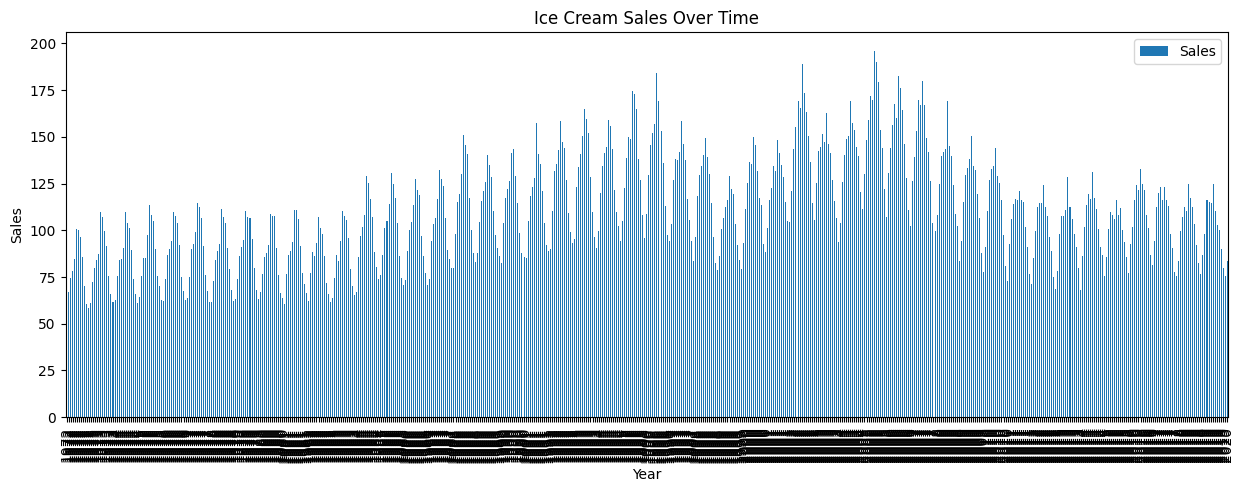

In [42]:
import matplotlib.pyplot as plt
df.plot.bar(x='Year',y='Sales',figsize=(15,5))
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Ice Cream Sales Over Time')
plt.show()

HORIZONTAL BAR GRAPH

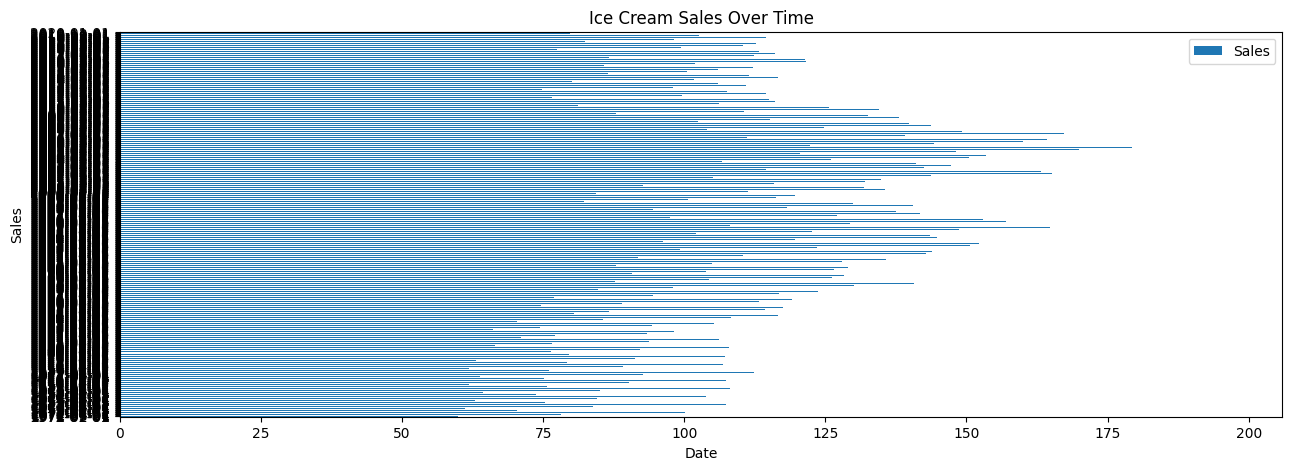

In [15]:
df.plot.barh(x='Date',y='Sales',figsize=(15,5))
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Ice Cream Sales Over Time')
plt.show()

SCATTER PLOT

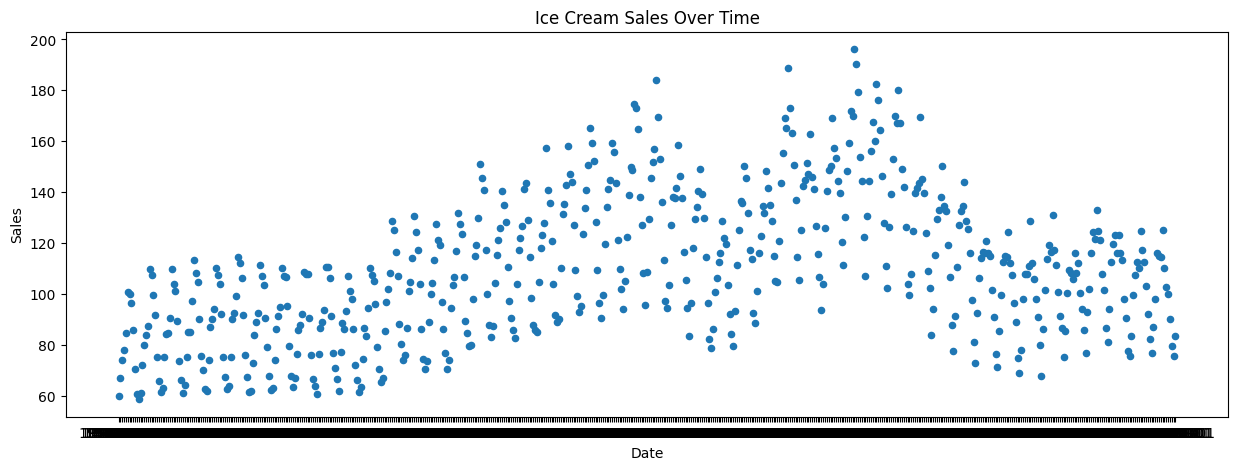

In [16]:
df.plot.scatter(x='Date',y='Sales',figsize=(15,5))
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Ice Cream Sales Over Time')
plt.show()

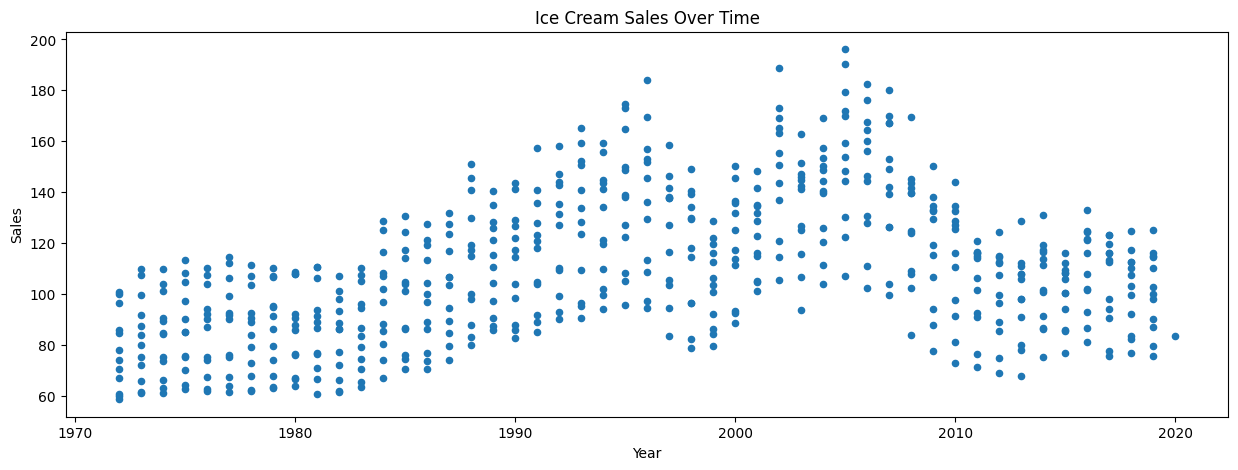

In [43]:
df.plot.scatter(x='Year',y='Sales',figsize=(15,5))
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Ice Cream Sales Over Time')
plt.show()

INDEPENDENT AND DEPENDENT FEATURES

In [45]:
df.head()

,Date,Sales,month,day,dayofweek,year,Year
0,1972-01-01,59.9622,1,1,5,1972,1972
1,1972-02-01,67.0605,2,1,1,1972,1972
2,1972-03-01,74.2350,3,1,2,1972,1972
3,1972-04-01,78.1120,4,1,5,1972,1972
4,1972-05-01,84.7636,5,1,0,1972,1972


In [46]:
X=df.iloc[:,2:-1]
Y=df.iloc[:,1:2]

In [53]:
X

,month,day,dayofweek,year
0,1,1,5,1972
1,2,1,1,1972
2,3,1,2,1972
3,4,1,5,1972
4,5,1,0,1972
...,...,...,...,...
572,9,1,6,2019
573,10,1,1,2019
574,11,1,4,2019
575,12,1,6,2019


In [54]:
Y

,Sales
0,59.9622
1,67.0605
2,74.2350
3,78.1120
4,84.7636
...,...
572,100.1741
573,90.1684
574,79.7223
575,75.7094


TRAIN TEST SPLIT

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=0)


In [61]:
X_train.shape

(519, 4)

In [62]:
X_test.shape

(58, 4)

In [63]:
Y_train.shape

(519, 1)

In [64]:
Y_test.shape

(58, 1)

STANDARIZING

In [65]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

MODEL TRAIN

In [66]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [68]:
import numpy as np
from sklearn.model_selection import cross_val_score
mse=cross_val_score(model,X_train,Y_train,scoring='neg_mean_squared_error',cv=5)
mean_mse=np.mean(mse)
print(mean_mse)

-641.7139845563167


PREDICTION

In [69]:
Y_predict=model.predict(X_test)

In [72]:
Y_predict

array([[100.81396929],
       [114.94905868],
       [ 99.82470749],
       [115.53128486],
       [105.47103705],
       [119.12260277],
       [ 97.12394888],
       [104.43565992],
       [109.6923593 ],
       [130.31859305],
       [110.72773643],
       [105.86270089],
       [129.25080953],
       [111.61829573],
       [ 98.51580813],
       [117.99333214],
       [118.24944892],
       [100.57081978],
       [130.23766683],
       [121.26057431],
       [117.06759111],
       [113.2836772 ],
       [ 93.69485426],
       [106.94382252],
       [106.28067012],
       [122.92595579],
       [120.14223729],
       [ 96.1698688 ],
       [105.50140977],
       [118.46148403],
       [115.54869031],
       [112.9947832 ],
       [100.52507529],
       [119.30426516],
       [126.53264547],
       [102.56027699],
       [ 91.57632182],
       [120.53186746],
       [109.61143307],
       [101.21860041],
       [ 98.03228446],
       [109.80846725],
       [120.86891047],
       [126

/tmp/ipykernel_769/502642458.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_test-Y_predict)


<Axes: ylabel='Density'>

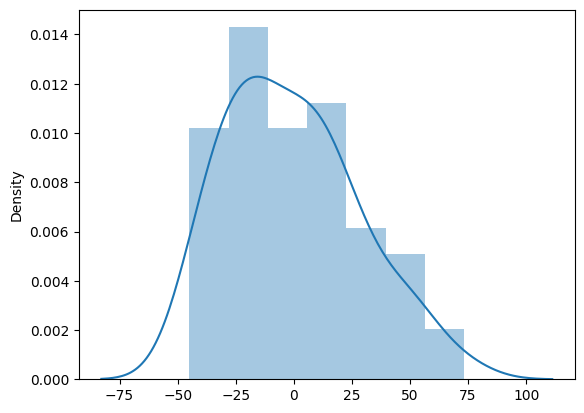

In [74]:
import seaborn as sns
sns.distplot(Y_test-Y_predict)

In [84]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,Y_predict)
r2

0.059018751022322014

In [78]:
print(Y_test.shape)
print(Y_predict.shape)

(58, 1)
(58, 1)


In [80]:
dfs=pd.DataFrame({'Actual':Y_test.squeeze(),'Predicted':Y_predict.squeeze()})
dfs.head()

,Actual,Predicted
162,124.5167,100.813969
428,141.9697,114.949059
263,90.5080,99.824707
490,74.8375,115.531285
334,84.3381,105.471037


In [81]:
dfs['Error']=dfs['Actual']-dfs['Predicted']

dfs.head()

,Actual,Predicted,Error
162,124.5167,100.813969,23.702731
428,141.9697,114.949059,27.020641
263,90.5080,99.824707,-9.316707
490,74.8375,115.531285,-40.693785
334,84.3381,105.471037,-21.132937


MEAN ABSOLUTE ERROR, MEAN SQUARED ERROR, ROOT MEAN SQUARED ERROR

In [86]:
from sklearn import metrics
print('MAE:',metrics.mean_absolute_error(Y_test,Y_predict))
print('MSE:',metrics.mean_squared_error(Y_test,Y_predict))
print('RMSE:',np.sqrt(metrics.mean_squared_error(Y_test,Y_predict)))

MAE: 23.44830724666072
MSE: 796.7886489260718
RMSE: 28.22744495922491


GRAPH

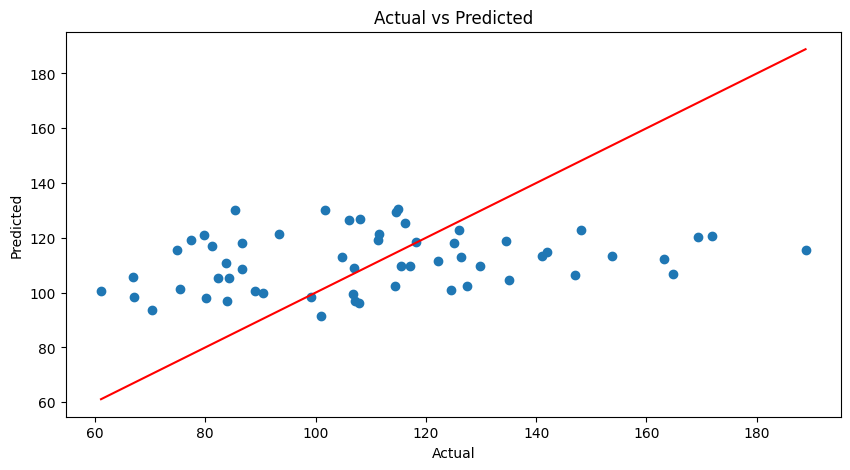

In [88]:
plt.figure(figsize=(10,5))
plt.scatter(Y_test,Y_predict)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()